In [112]:
import pandas as pd
data=pd.read_csv("affairs.csv")
print(data)


     rownames  gender   age  yearsmarried children  religiousness  education  \
0           4    male  37.0         10.00       no              3         18   
1           5  female  27.0          4.00       no              4         14   
2          11  female  32.0         15.00      yes              1         12   
3          16    male  57.0         15.00      yes              5         18   
4          23    male  22.0          0.75       no              2         17   
..        ...     ...   ...           ...      ...            ...        ...   
596      1938    male  22.0          1.50      yes              1         12   
597      1941  female  32.0         10.00      yes              2         18   
598      1954    male  32.0         10.00      yes              2         17   
599      1959    male  22.0          7.00      yes              3         18   
600      9010  female  32.0         15.00      yes              3         14   

     occupation  rating  affairs  
0   

In [113]:
data.isnull().sum()

,0
rownames,0
gender,0
age,0
yearsmarried,0
children,0
religiousness,0
education,0
occupation,0
rating,0
affairs,0


In [114]:
from sklearn.preprocessing import LabelEncoder
b=LabelEncoder()
data["gender"]=b.fit_transform(data["gender"])
data["children"]=b.fit_transform(data["children"])
print(data)

     rownames  gender   age  yearsmarried  children  religiousness  education  \
0           4       1  37.0         10.00         0              3         18   
1           5       0  27.0          4.00         0              4         14   
2          11       0  32.0         15.00         1              1         12   
3          16       1  57.0         15.00         1              5         18   
4          23       1  22.0          0.75         0              2         17   
..        ...     ...   ...           ...       ...            ...        ...   
596      1938       1  22.0          1.50         1              1         12   
597      1941       0  32.0         10.00         1              2         18   
598      1954       1  32.0         10.00         1              2         17   
599      1959       1  22.0          7.00         1              3         18   
600      9010       0  32.0         15.00         1              3         14   

     occupation  rating  af

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rownames       601 non-null    int64  
 1   gender         601 non-null    int64  
 2   age            601 non-null    float64
 3   yearsmarried   601 non-null    float64
 4   children       601 non-null    int64  
 5   religiousness  601 non-null    int64  
 6   education      601 non-null    int64  
 7   occupation     601 non-null    int64  
 8   rating         601 non-null    int64  
 9   affairs        601 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 47.1 KB


In [116]:
data.describe()

,rownames,gender,age,yearsmarried,children,religiousness,education,occupation,rating,affairs
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,1059.722130,0.475874,32.487521,8.177696,0.715474,3.116473,16.166389,4.194676,3.931780,1.455907
std,914.904611,0.499834,9.288762,5.571303,0.451564,1.167509,2.402555,1.819443,1.103179,3.298758
min,4.000000,0.000000,17.500000,0.125000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,528.000000,0.000000,27.000000,4.000000,0.000000,2.000000,14.000000,3.000000,3.000000,0.000000
50%,1009.000000,0.000000,32.000000,7.000000,1.000000,3.000000,16.000000,5.000000,4.000000,0.000000
75%,1453.000000,1.000000,37.000000,15.000000,1.000000,4.000000,18.000000,6.000000,5.000000,0.000000
max,9029.000000,1.000000,57.000000,15.000000,1.000000,5.000000,20.000000,7.000000,5.000000,12.000000


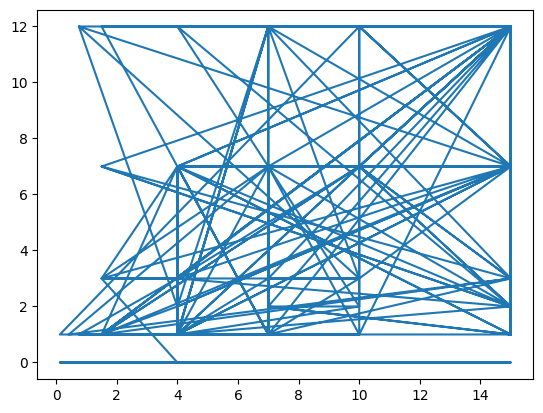

In [117]:
from matplotlib import pyplot as plt
plt.plot(data["yearsmarried"],data["affairs"])

<BarContainer object of 601 artists>

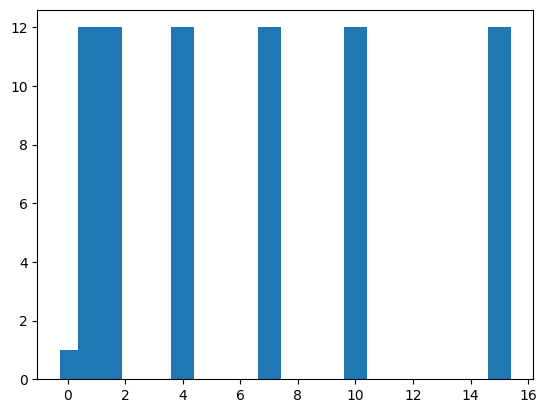

In [118]:
plt.bar(data["yearsmarried"],data["affairs"])

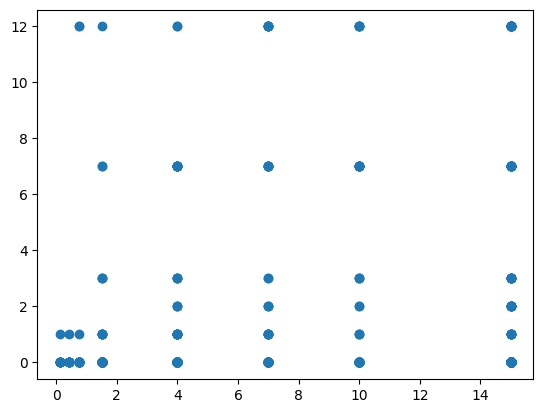

In [119]:
plt.scatter(data["yearsmarried"],data["affairs"])

(array([485.,  17.,  19.,   0.,   0.,  42.,   0.,   0.,   0.,  38.]),
 array([ 0. ,  1.2,  2.4,  3.6,  4.8,  6. ,  7.2,  8.4,  9.6, 10.8, 12. ]),
 <BarContainer object of 10 artists>)

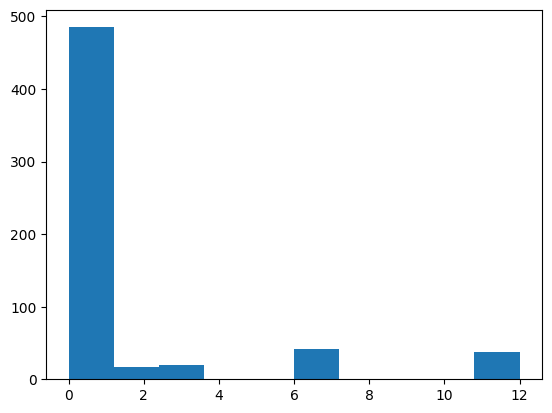

In [120]:
plt.hist(data["affairs"])

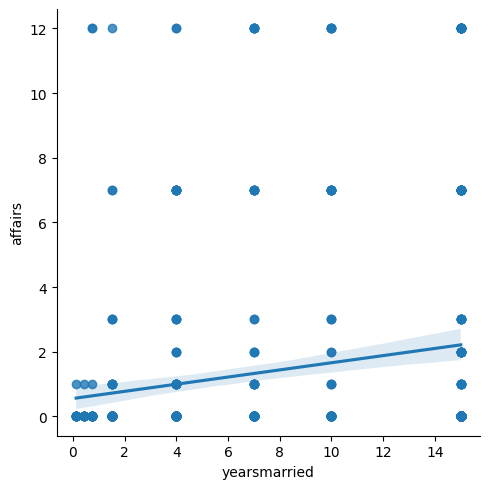

In [121]:
import seaborn as sns
sns.lmplot(x="yearsmarried",y="affairs",data=data)

<Axes: xlabel='yearsmarried', ylabel='affairs'>

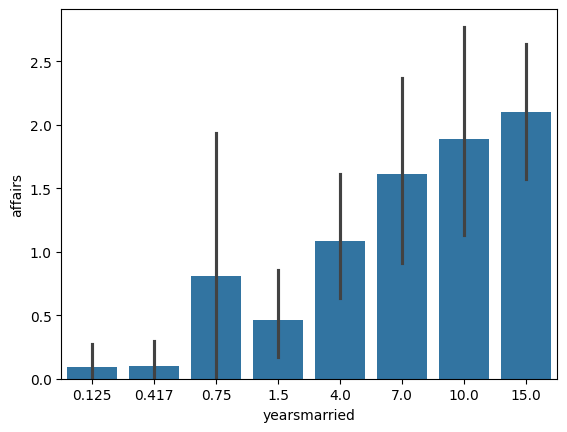

In [122]:
sns.barplot(x="yearsmarried",y="affairs",data=data)

<Axes: xlabel='yearsmarried', ylabel='affairs'>

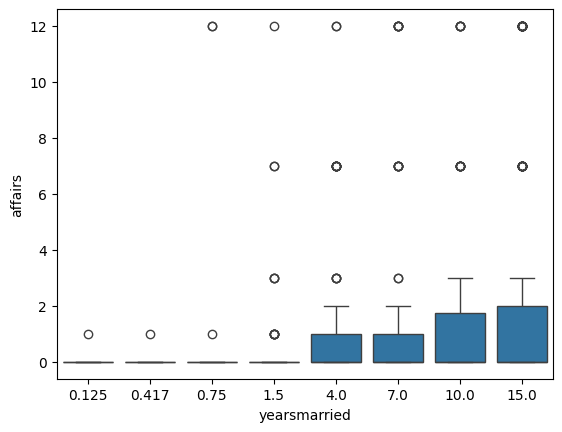

In [123]:
sns.boxplot(x="yearsmarried",y="affairs",data=data)

<Axes: xlabel='yearsmarried', ylabel='affairs'>

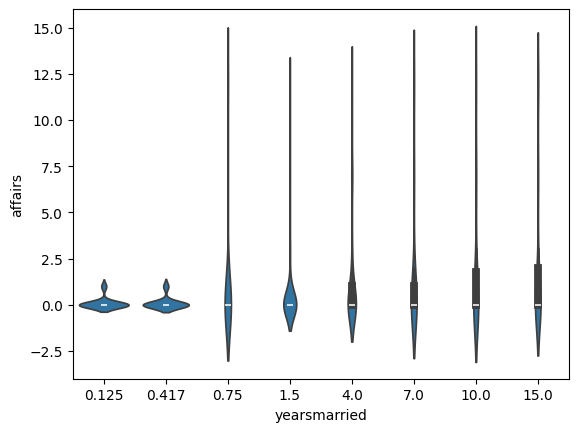

In [124]:
sns.violinplot(x="yearsmarried",y="affairs",data=data)

<Axes: xlabel='affairs', ylabel='Density'>

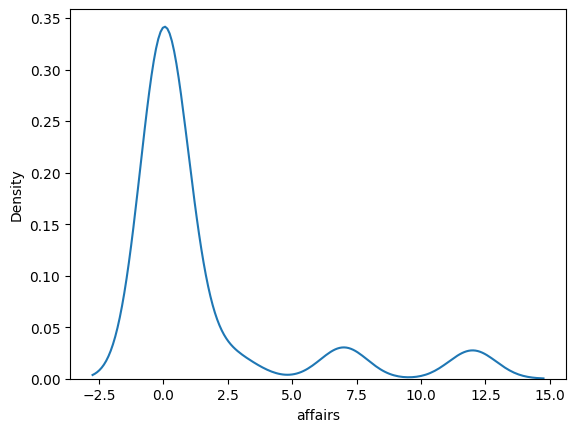

In [125]:
sns.kdeplot(x="affairs",data=data)

/tmp/ipython-input-126-2277639693.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["affairs"])


<Axes: xlabel='affairs', ylabel='Density'>

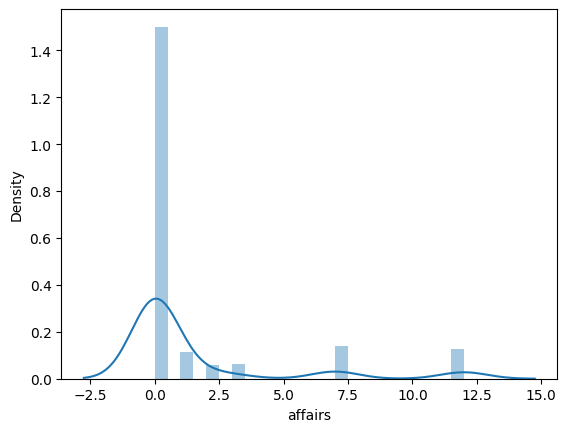

In [126]:
sns.distplot(data["affairs"])

<Axes: >

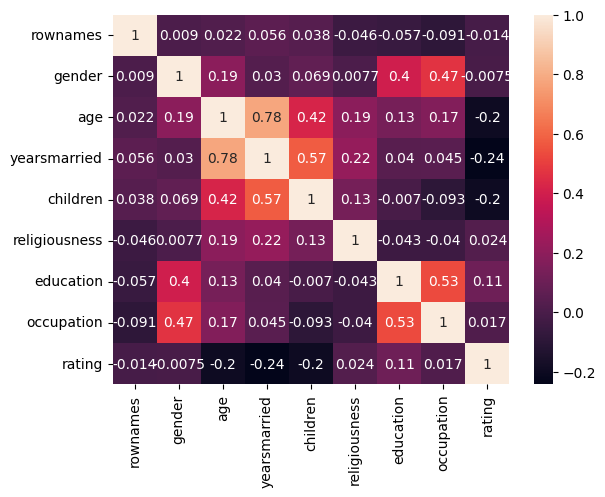

In [127]:
a=data.drop("affairs",axis=1).corr()
sns.heatmap(a,annot=True)

In [128]:
x=data.drop("affairs",axis=1)
y=data["affairs"]
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [129]:
print(x)

     rownames  gender   age  yearsmarried  children  religiousness  education  \
0           4       1  37.0         10.00         0              3         18   
1           5       0  27.0          4.00         0              4         14   
2          11       0  32.0         15.00         1              1         12   
3          16       1  57.0         15.00         1              5         18   
4          23       1  22.0          0.75         0              2         17   
..        ...     ...   ...           ...       ...            ...        ...   
596      1938       1  22.0          1.50         1              1         12   
597      1941       0  32.0         10.00         1              2         18   
598      1954       1  32.0         10.00         1              2         17   
599      1959       1  22.0          7.00         1              3         18   
600      9010       0  32.0         15.00         1              3         14   

     occupation  rating  
0

In [130]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
596    1
597    7
598    2
599    2
600    1
Name: affairs, Length: 601, dtype: int64


In [131]:
print(xtrain)

     rownames  gender   age  yearsmarried  children  religiousness  education  \
110       547       0  32.0           7.0         1              4         17   
312      1341       1  47.0          15.0         1              5         14   
536      1075       1  37.0          10.0         1              2         20   
211       950       1  22.0           4.0         0              2         18   
112       558       0  32.0           1.5         0              5         18   
..        ...     ...   ...           ...       ...            ...        ...   
66        355       1  37.0          10.0         1              4         20   
381      1638       1  52.0          15.0         1              4         16   
8          47       0  32.0          15.0         1              4         16   
500       611       1  47.0          15.0         1              5         16   
511       770       1  42.0          15.0         1              4         20   

     occupation  rating  
1

In [132]:
print(xtest)

     rownames  gender   age  yearsmarried  children  religiousness  education  \
397      1726       0  22.0          0.75         0              1         14   
400      1754       1  27.0          4.00         1              5         17   
373      1608       0  27.0          1.50         0              4         17   
247      1102       0  42.0         15.00         1              4         14   
565      1575       0  27.0         10.00         1              4         14   
..        ...     ...   ...           ...       ...            ...        ...   
522       951       1  32.0          7.00         1              2         12   
83        418       1  42.0          4.00         0              4         17   
391      1698       1  42.0         15.00         1              4         16   
35        172       0  22.0          1.50         0              4         16   
182       859       0  32.0          4.00         1              3         17   

     occupation  rating  
3

In [133]:
print(ytrain)

110     0
312     0
536    12
211     0
112     0
       ..
66      0
381     0
8       0
500     3
511     7
Name: affairs, Length: 480, dtype: int64


In [134]:
print(ytest)

397     0
400     0
373     0
247     0
565     2
       ..
522    12
83      0
391     0
35      0
182     0
Name: affairs, Length: 121, dtype: int64


In [135]:
from sklearn.linear_model import LogisticRegression
b = LogisticRegression()
b.fit(xtrain, ytrain)
ypred = b.predict(xtest)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [136]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest,ypred))


0.7768595041322314


In [137]:
a=b.predict([[4,1,37,10,0,3,18,7,4]])
print(a)

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [138]:
a=b.predict([[71,0,37,10,2,3,9,7,7]])
print(a)

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [139]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(ytest,ypred))

[[94  0  0  0  0  0]
 [ 4  0  0  0  0  0]
 [ 3  0  0  0  0  0]
 [ 5  0  0  0  0  0]
 [ 7  0  0  0  0  0]
 [ 8  0  0  0  0  0]]
